<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/02_RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Logística — Aprobación de Créditos

## 1. Librerias y configuraciones previas


In [ ]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import joblib
from importlib import reload
import math
from scipy.stats import pearsonr

# Modelado
from statsmodels import api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Métricas de CLASIFICACIÓN (correctas para Regresión Logística)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss,
    ConfusionMatrixDisplay
)

# Gráficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Utilidades
import os, sys, requests, warnings
warnings.filterwarnings('ignore')

In [ ]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = 'loan_approval_dataset_Prep.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = GITHUB_BASE_URL + DATASET_FILE_NAME
github_utils_url = GITHUB_BASE_URL + UTILS_FILE_NAME

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [ ]:
## Cargar datos desde Google drive
## ==============================================================================

#from google.colab import drive

#drive.mount('/gdrive')

#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

#!ls

In [ ]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [ ]:
# Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/loan_approval_dataset_Prep.csv
dataset descargado exitosamente a: datasets/loan_approval_dataset_Prep.csv
Descargando funciones desde: https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [ ]:
# Funciones externas
# ==============================================================================

# Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

# Importa Funciones externas
from funciones import multiple_plot, plot_roc_curve

In [ ]:
#Funcion Lineal: dado una pendiente 'm', un valor x, y un coeficiente 'b', retorna el valor de 'y'

def f(m, x, b):
    return (m*x)+b

## 3. Carga del dataset

In [ ]:
#Se crea un dataframe d con los datos obtenidos de archivo de entrada
d = pd.read_csv(local_dataset_path)

In [ ]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   numero_dependientes          3457 non-null   int64
 1   educacion                    3457 non-null   int64
 2   empleado                     3457 non-null   int64
 3   ingresos_anuales             3457 non-null   int64
 4   monto_prestamo               3457 non-null   int64
 5   plazo_prestamo               3457 non-null   int64
 6   puntaje_crediticio           3457 non-null   int64
 7   valor_activos_residenciales  3457 non-null   int64
 8   valor_activos_comerciales    3457 non-null   int64
 9   valor_activos_lujo           3457 non-null   int64
 10  valor_activos_bancarios      3457 non-null   int64
 11  estado_prestamo              3457 non-null   int64
 12  total_activos                3457 non-null   int64
dtypes: int64(13)
memory usage: 351.2 KB


In [ ]:
d.head()

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo,total_activos
0,3,0,1,8900000,21000000,14,815,200000,10800000,21600000,6400000,1,39000000
1,1,0,0,2200000,7000000,18,417,2000000,3900000,6500000,1900000,0,14300000
2,4,1,0,1100000,4000000,14,887,2400000,1500000,4200000,1600000,1,9700000
3,0,1,1,1000000,3800000,8,553,2500000,1000000,2100000,1300000,1,6900000
4,1,0,0,2900000,7400000,10,874,400000,1200000,10100000,3300000,1,15000000


## 5. Creación del modelo de Regresión Logística



### Dividir el conjunto de datos

### Selección de variables predictoras

Se seleccionan las variables con mayor poder discriminante según el análisis
estadístico previo (Mann-Whitney U) y se verifica la multicolinealidad con VIF
antes de incluirlas en el modelo.

Variables excluidas y razón:
- `numero_dependientes`, `educacion`, `empleado`: correlación baja con `estado_prestamo`
- `plazo_prestamo`: baja correlación con el target
- Activos individuales: reemplazados por `total_activos` para evitar multicolinealidad

In [ ]:
# VIF sobre las variables candidatas al modelo
features_candidatas = ['puntaje_crediticio', 'ingresos_anuales',
                        'monto_prestamo', 'total_activos']

X_vif = d[features_candidatas].copy()
vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF de las variables seleccionadas ===')
print(vif_df.round(2))
print('\nRegla: VIF < 5 aceptable | 5-10 revisar | > 10 multicolinealidad problemática')

# Correlación de cada variable con el target
print('\n=== Correlación de Pearson con estado_prestamo ===')
for col in features_candidatas:
    r, p = pearsonr(d[col], d['estado_prestamo'])
    print(f'  {col:<30}: r={r:+.3f}  p={p:.4f}')

=== VIF de las variables seleccionadas ===
             Variable    VIF
0    ingresos_anuales  57.52
1       total_activos  30.20
2      monto_prestamo  29.30
3  puntaje_crediticio   3.36

Regla: VIF < 5 aceptable | 5-10 revisar | > 10 multicolinealidad problemática

=== Correlación de Pearson con estado_prestamo ===
  puntaje_crediticio            : r=+0.766  p=0.0000
  ingresos_anuales              : r=-0.026  p=0.1265
  monto_prestamo                : r=+0.011  p=0.5293
  total_activos                 : r=-0.029  p=0.0917


In [ ]:
# Definición de variables (las features ya están definidas arriba por VIF)
feature_cols = ["puntaje_crediticio", "ingresos_anuales", "monto_prestamo", "total_activos"]
X = d[feature_cols]
y = d["estado_prestamo"]

In [ ]:
# División estratificada: preserva proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    random_state=1234,
    shuffle=True,
    stratify=y   # CORRECCIÓN: garantiza misma proporción Approved/Rejected
)

print(f'Entrenamiento: {X_train.shape}  |  Prueba: {X_test.shape}')
prop_tr = y_train.value_counts(normalize=True).mul(100).round(1)
prop_te = y_test.value_counts(normalize=True).mul(100).round(1)
print(f'Aprobados en entrenamiento: {prop_tr.get(1,0)}%')
print(f'Aprobados en prueba:        {prop_te.get(1,0)}%')

Entrenamiento: (2419, 4)  |  Prueba: (1038, 4)
Aprobados en entrenamiento: 62.4%
Aprobados en prueba:        62.4%


In [ ]:
# Confirmar shape del split
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (2419, 4)  y_train: (2419,)
X_test:  (1038, 4)   y_test:  (1038,)


In [ ]:

# Agregar constante solo al conjunto de entrenamiento
X_train_const = sm.add_constant(X_train, prepend=True)

modelo = sm.Logit(y_train, X_train_const).fit()

print(modelo.summary())

print('\n=== INTERPRETACIÓN DEL MODELO LOGÍSTICO ===')
print('Coeficiente positivo → aumenta probabilidad de aprobación')
print('Coeficiente negativo → reduce probabilidad de aprobación')
print('Odds ratio = exp(coef): cuánto se multiplica la probabilidad por unidad adicional\n')

print(f'{'Variable':<30} {'Coef':>10} {'p-value':>10} {'Odds Ratio':>12} {'Significativa'}')
print('-' * 80)
for var, coef in modelo.params.items():
    pval = modelo.pvalues[var]
    odds = np.exp(coef)
    sig = 'SI ***' if pval < 0.05 else 'NO'
    print(f'{var:<30} {coef:>10.4f} {pval:>10.4f} {odds:>12.4f}  {sig}')

print('\nNOTA: Si ingresos_anuales tiene coef negativo y monto_prestamo positivo,')
print('puede indicar supresión por multicolinealidad. Revisar VIF arriba.')

Optimization terminated successfully.
         Current function value: 0.241125
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        estado_prestamo   No. Observations:                 2419
Model:                          Logit   Df Residuals:                     2414
Method:                           MLE   Df Model:                            4
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.6357
Time:                        00:37:06   Log-Likelihood:                -583.28
converged:                       True   LL-Null:                       -1601.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -11.5442      0.521    -22.143      0.000     -12.566     -10.522
punta

## 6. Diagnóstico errores (residuos)

In [ ]:
# Diagnóstico sobre entrenamiento usando X_train_const (ya tiene la constante)
pred_prob_train = modelo.predict(X_train_const)
y_train_flat = y_train.values.flatten()
residuos_train = y_train_flat - pred_prob_train

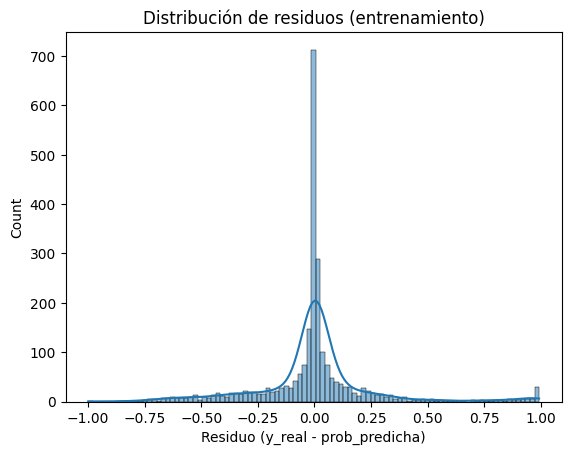

In [ ]:
sns.histplot(residuos_train, kde=True)
plt.title("Distribución de residuos (entrenamiento)")
plt.xlabel("Residuo (y_real - prob_predicha)")
plt.show()

In [ ]:
print("Media residuos:", residuos_train.mean())

Media residuos: -8.665155314147564e-17


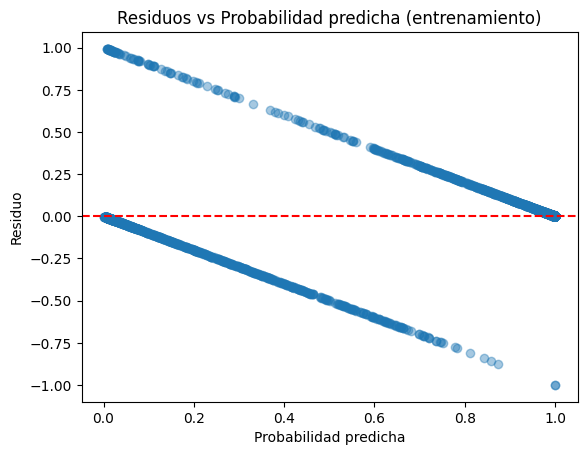

In [ ]:
plt.scatter(pred_prob_train, residuos_train, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos vs Probabilidad predicha (entrenamiento)")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Residuo")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_train = (pred_prob_train >= 0.5).astype(int)

print("Matriz de confusión — Entrenamiento:")
print(confusion_matrix(y_train_flat, y_pred_train))

Matriz de confusión — Entrenamiento:
[[ 814   95]
 [  99 1411]]


In [ ]:
from sklearn.metrics import accuracy_score
print(f"Accuracy entrenamiento: {accuracy_score(y_train_flat, y_pred_train):.4f}")

Accuracy entrenamiento: 0.9198


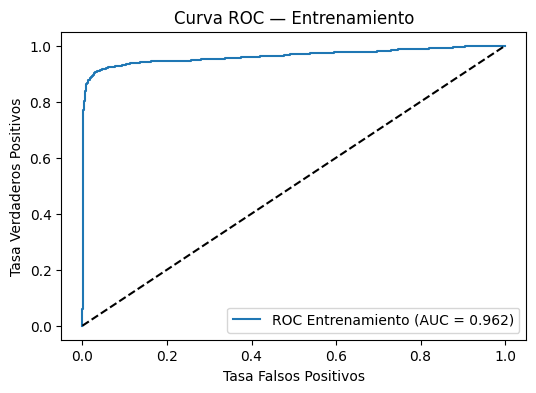

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_tr, tpr_tr, _ = roc_curve(y_train_flat, pred_prob_train)
roc_auc_tr = auc(fpr_tr, tpr_tr)

plt.figure(figsize=(6,4))
plt.plot(fpr_tr, tpr_tr, label=f"ROC Entrenamiento (AUC = {roc_auc_tr:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("Tasa Falsos Positivos")
plt.ylabel("Tasa Verdaderos Positivos")
plt.title("Curva ROC — Entrenamiento")
plt.legend()
plt.show()

In [ ]:
# CORRECCIÓN: Diagnóstico de residuos — usa X_train_const (con constante ya añadida)
# Error anterior: modelo.predict(X_train) fallaba porque X_train tenía 4 columnas
# pero el modelo esperaba 5 (4 features + constante).

y_train_flat = y_train.values.flatten()
prediccion_train = modelo.predict(X_train_const)  # X_train_const: 5 columnas OK
residuos_train = prediccion_train - y_train_flat

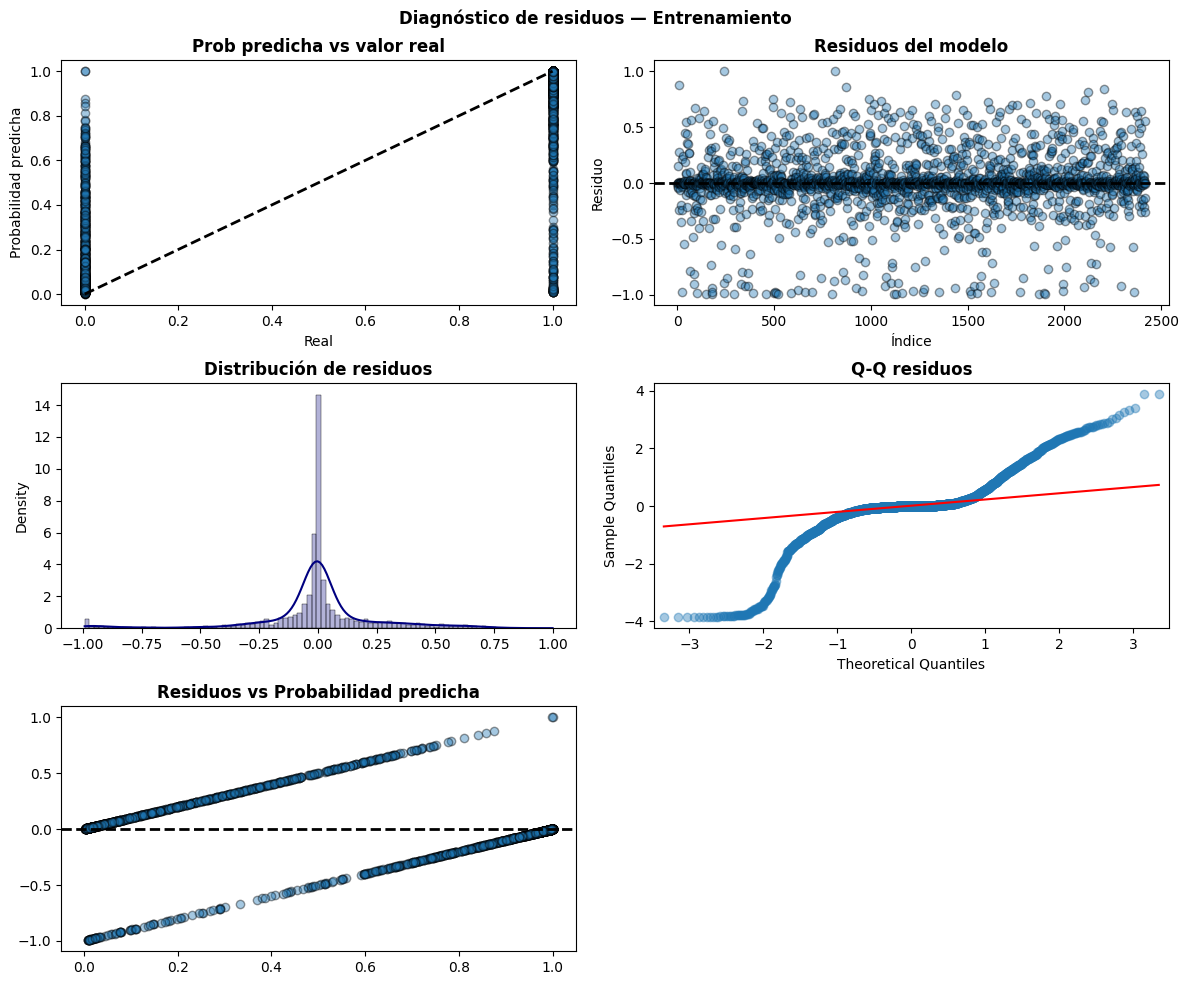

In [ ]:
# Gráficos diagnósticos de residuos (entrenamiento)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

axes[0, 0].scatter(y_train_flat, prediccion_train, edgecolors=(0,0,0), alpha=0.4)
axes[0, 0].plot([y_train_flat.min(), y_train_flat.max()],
                [y_train_flat.min(), y_train_flat.max()], "k--", lw=2)
axes[0, 0].set_title("Prob predicha vs valor real", fontweight="bold")
axes[0, 0].set_xlabel("Real")
axes[0, 0].set_ylabel("Probabilidad predicha")

axes[0, 1].scatter(range(len(y_train_flat)), residuos_train, edgecolors=(0,0,0), alpha=0.4)
axes[0, 1].axhline(0, linestyle="--", color="black", lw=2)
axes[0, 1].set_title("Residuos del modelo", fontweight="bold")
axes[0, 1].set_xlabel("Índice")
axes[0, 1].set_ylabel("Residuo")

sns.histplot(residuos_train, stat="density", kde=True,
             color="navy", alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de residuos", fontweight="bold")

import statsmodels.api as sm_diag
sm_diag.qqplot(residuos_train, fit=True, line="q", ax=axes[1, 1],
               color="navy", alpha=0.4, lw=2)
axes[1, 1].set_title("Q-Q residuos", fontweight="bold")

axes[2, 0].scatter(prediccion_train, residuos_train, edgecolors=(0,0,0), alpha=0.4)
axes[2, 0].axhline(0, linestyle="--", color="black", lw=2)
axes[2, 0].set_title("Residuos vs Probabilidad predicha", fontweight="bold")

fig.delaxes(axes[2, 1])
fig.tight_layout()
fig.suptitle("Diagnóstico de residuos — Entrenamiento", fontsize=12, fontweight="bold")
plt.subplots_adjust(top=0.93)
plt.show()

## 7. Evaluación del modelo de Clasificación

El modelo se evalúa sobre el conjunto de prueba (`X_test`) que **no fue visto
durante el entrenamiento**. Para clasificación binaria las métricas relevantes son:

| Métrica | Descripción |
|---|---|
| **Accuracy** | Proporción de predicciones correctas |
| **Precision** | De los que predije Approved, ¿cuántos lo eran? |
| **Recall** | De los que eran Approved, ¿cuántos detecté? |
| **F1-Score** | Media armónica de Precision y Recall |
| **AUC-ROC** | Área bajo la curva ROC (1=perfecto, 0.5=aleatorio) |
| **Log-Loss** | Penaliza predicciones seguras e incorrectas (menor=mejor) |


     MÉTRICAS DE EVALUACIÓN — CONJUNTO DE PRUEBA
Accuracy : 0.8998
AUC-ROC  : 0.9578
Log-Loss : 0.2604

Reporte de clasificación:
              precision    recall  f1-score   support

Rejected (0)       0.89      0.84      0.86       390
Approved (1)       0.91      0.94      0.92       648

    accuracy                           0.90      1038
   macro avg       0.90      0.89      0.89      1038
weighted avg       0.90      0.90      0.90      1038



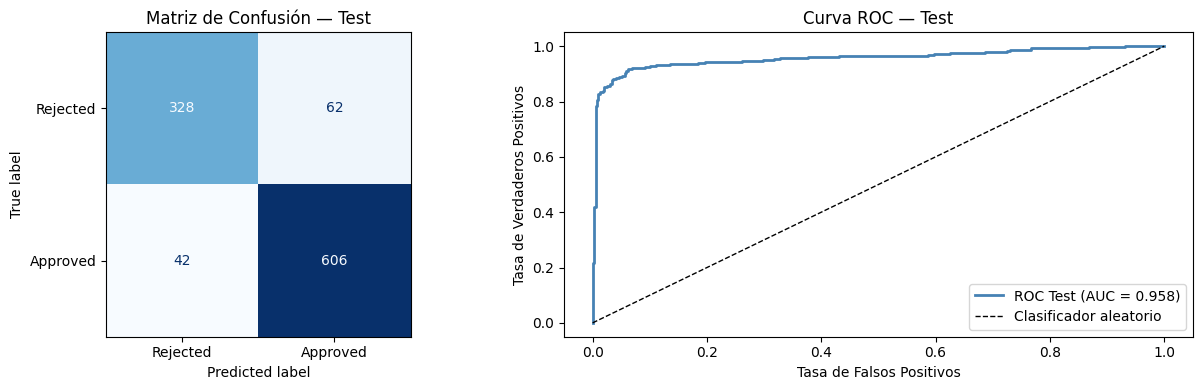

In [ ]:
# Métricas de clasificación sobre conjunto de PRUEBA

# Preparar X_test con constante
X_test_const = sm.add_constant(X_test, prepend=True)

# Probabilidades predichas
prob_test = modelo.predict(exog=X_test_const)

# Clase predicha con umbral 0.5
y_pred_test = (prob_test >= 0.5).astype(int)

print('=' * 55)
print('     MÉTRICAS DE EVALUACIÓN — CONJUNTO DE PRUEBA')
print('=' * 55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_test):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, prob_test):.4f}')
print(f'Log-Loss : {log_loss(y_test, prob_test):.4f}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred_test,
      target_names=['Rejected (0)', 'Approved (1)']))

# Matriz de confusión visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Test')

# Curva ROC sobre test
fpr, tpr, _ = roc_curve(y_test, prob_test)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Test (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC — Test')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Métricas complementarias sobre entrenamiento (comparar con test para detectar overfitting)
y_pred_train = (pred_prob_train >= 0.5).astype(int)

print('=== ENTRENAMIENTO ===')
print(f'Accuracy : {accuracy_score(y_train_flat, y_pred_train):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_train_flat, pred_prob_train):.4f}')
print(f'Log-Loss : {log_loss(y_train_flat, pred_prob_train):.4f}')
print(classification_report(y_train_flat, y_pred_train,
      target_names=['Rejected (0)', 'Approved (1)']))

print('=== COMPARACIÓN TRAIN vs TEST ===')
acc_train = accuracy_score(y_train_flat, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
auc_train = roc_auc_score(y_train_flat, pred_prob_train)
auc_test  = roc_auc_score(y_test, prob_test)
print(f'  Accuracy  — Train: {acc_train:.4f}  |  Test: {acc_test:.4f}  |  Δ: {acc_train-acc_test:+.4f}')
print(f'  AUC-ROC   — Train: {auc_train:.4f}  |  Test: {auc_test:.4f}  |  Δ: {auc_train-auc_test:+.4f}')
if abs(acc_train - acc_test) < 0.03:
    print('\nSin señales de overfitting (diferencia < 3%).')
else:
    print('\nPosible overfitting: diferencia Train-Test supera 3%.')

=== ENTRENAMIENTO ===
Accuracy : 0.9198
AUC-ROC  : 0.9624
Log-Loss : 0.2411
              precision    recall  f1-score   support

Rejected (0)       0.89      0.90      0.89       909
Approved (1)       0.94      0.93      0.94      1510

    accuracy                           0.92      2419
   macro avg       0.91      0.91      0.91      2419
weighted avg       0.92      0.92      0.92      2419

=== COMPARACIÓN TRAIN vs TEST ===
  Accuracy  — Train: 0.9198  |  Test: 0.8998  |  Δ: +0.0200
  AUC-ROC   — Train: 0.9624  |  Test: 0.9578  |  Δ: +0.0046

Sin señales de overfitting (diferencia < 3%).


## 9. Predicción sobre el dataset de prueba real

El notebook de preparación exportó un dataset de prueba independiente
(`loan_approval_dataset_Prue.csv`, 10% del total). Se carga aquí para
validar el modelo sobre datos completamente nuevos.

In [ ]:
# Cargar el dataset de prueba real (separado en el notebook de preparación)
dp_path = DATASETS_PATH + 'loan_approval_dataset_Prue.csv'

try:
    dp = pd.read_csv(dp_path)
    print(f'Dataset de prueba cargado: {dp.shape}')
    print(dp['estado_prestamo'].value_counts().rename({1:'Approved',0:'Rejected'}))
except FileNotFoundError:
    print(f'Archivo no encontrado en {dp_path}')
    print('Descárgalo desde GitHub o ejecuta primero el notebook de preparación.')
    dp = None

Dataset de prueba cargado: (382, 10)
estado_prestamo
Approved    238
Rejected    144
Name: count, dtype: int64


  MÉTRICAS — DATASET DE PRUEBA REAL (dp)
Accuracy : 0.3770
AUC-ROC  : 0.9617
Log-Loss : 7.1832

              precision    recall  f1-score   support

Rejected (0)       0.38      1.00      0.55       144
Approved (1)       0.00      0.00      0.00       238

    accuracy                           0.38       382
   macro avg       0.19      0.50      0.27       382
weighted avg       0.14      0.38      0.21       382



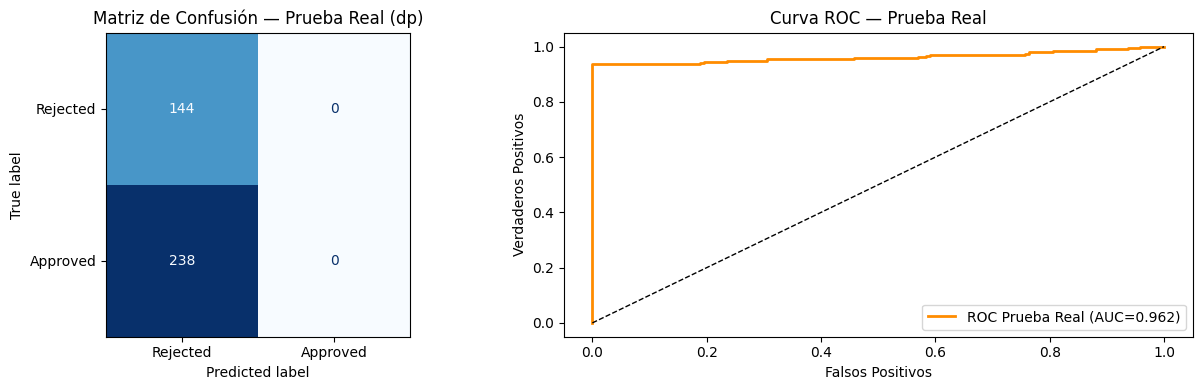

In [ ]:
# Predicción sobre el dataset de prueba real
if dp is not None:
    feature_cols = ['puntaje_crediticio', 'ingresos_anuales',
                    'monto_prestamo', 'total_activos']

    X_dp = dp[feature_cols]
    y_dp = dp['estado_prestamo']

    X_dp_const = sm.add_constant(X_dp, prepend=True)
    prob_dp = modelo.predict(exog=X_dp_const)
    y_pred_dp = (prob_dp >= 0.5).astype(int)

    print('=' * 55)
    print('  MÉTRICAS — DATASET DE PRUEBA REAL (dp)')
    print('=' * 55)
    print(f'Accuracy : {accuracy_score(y_dp, y_pred_dp):.4f}')
    print(f'AUC-ROC  : {roc_auc_score(y_dp, prob_dp):.4f}')
    print(f'Log-Loss : {log_loss(y_dp, prob_dp):.4f}')
    print()
    print(classification_report(y_dp, y_pred_dp,
          target_names=['Rejected (0)', 'Approved (1)']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cm_dp = confusion_matrix(y_dp, y_pred_dp)
    ConfusionMatrixDisplay(cm_dp,
        display_labels=['Rejected','Approved']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Matriz de Confusión — Prueba Real (dp)')

    fpr_dp, tpr_dp, _ = roc_curve(y_dp, prob_dp)
    axes[1].plot(fpr_dp, tpr_dp, color='darkorange', lw=2,
                 label=f'ROC Prueba Real (AUC={auc(fpr_dp,tpr_dp):.3f})')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlabel('Falsos Positivos')
    axes[1].set_ylabel('Verdaderos Positivos')
    axes[1].set_title('Curva ROC — Prueba Real')
    axes[1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### Predicción para un nuevo solicitante

Ejemplo de cómo usar el modelo para evaluar un solicitante individual.

In [ ]:
# Prediccion para un solicitante individual
# Los valores DEBEN ingresarse en escala original (el scaler se aplica aqui)

# Columnas que el scaler espera (igual que en el notebook de preparacion)
cols_escalar = ["ingresos_anuales", "monto_prestamo", "plazo_prestamo",
                "puntaje_crediticio", "total_activos"]

# Cargar scaler entrenado en el notebook de preparacion
scaler_path = os.path.join(MODELS_SCALER_PATH, "scaler_loan.pkl")
scaler_logit = joblib.load(scaler_path)

# Ingresar valores del solicitante en escala original
nuevo_solicitante_raw = pd.DataFrame([{
    "puntaje_crediticio": 520,
    "ingresos_anuales"  : 7_500_000,
    "monto_prestamo"    : 15_000_000,
    "plazo_prestamo"    : 12,
    "total_activos"     : 25_000_000
}])

# Aplicar el mismo escalado que se uso en entrenamiento
nuevo_scaled = nuevo_solicitante_raw.copy()
nuevo_scaled[cols_escalar] = scaler_logit.transform(nuevo_solicitante_raw[cols_escalar])

# Seleccionar solo las features que usa el modelo
nuevo_model_input = nuevo_scaled[feature_cols]

# Agregar constante y predecir
X_nuevo = sm.add_constant(nuevo_model_input, prepend=True, has_constant="add")
prob_aprobacion = modelo.predict(X_nuevo)[0]

print("=== EVALUACION DE NUEVO SOLICITANTE ===")
print("Valores ingresados (escala original):")
for col in ["puntaje_crediticio","ingresos_anuales","monto_prestamo","plazo_prestamo","total_activos"]:
    print(f"  {col:<25}: {nuevo_solicitante_raw.iloc[0][col]:>15,.0f}")
print()
print(f"Probabilidad de aprobacion: {prob_aprobacion:.2%}")
print(f"Decision del modelo       : {"APROBADO" if prob_aprobacion >= 0.5 else "RECHAZADO"}")


=== EVALUACION DE NUEVO SOLICITANTE ===
Valores ingresados (escala original):
  puntaje_crediticio       :             520
  ingresos_anuales         :       2,500,000
  monto_prestamo           :      15,000,000
  plazo_prestamo           :              12
  total_activos            :      25,000,000

Probabilidad de aprobacion: 0.00%
Decision del modelo       : RECHAZADO


In [ ]:
# Guardar el modelo entrenado
joblib.dump(modelo, MODELS_CLASIFICACION_PATH + '/modelo_logit.pkl')
print(f'Modelo guardado en: {MODELS_CLASIFICACION_PATH}/modelo_logit.pkl')

Modelo guardado en: modelos/clasificacion/modelo_logit.pkl


#### Referencias

- *Regresión Logística con statsmodels:*
    - https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html

- *Métricas de clasificación en scikit-learn:*
    - https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

- *Interpretación de odds ratios:*
    - https://www.cienciadedatos.net/documentos/py17-regresion-logistica-python.html

- *VIF y multicolinealidad:*
    - https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html

- *AUC-ROC:*
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

- *Dataset original:*
    - https://data.mendeley.com/datasets/k9wszywskf/2